In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
)

In [2]:
br = load_breast_cancer() # Load the breast cancer dataset from sklearn's built-in datasets.
X = br.data # Feature matrix (input variables) containing measurements of tumors.
y = br.target # Target vector (output variable) indicating whether the tumor is malignant (1) or benign (0).

print(f"Feature names: {br.feature_names}")
print(f"Target classes: {br.target_names}")
print(f"Data shape: {X.shape} (samples, features)")

Feature names: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']
Target classes: ['malignant' 'benign']
Data shape: (569, 30) (samples, features)


In [4]:
print("First 5 rows of features:")
print(X[:5]) #display the first five rows of your feature matrix X
print("\nFirst 5 target labels:", y[:5]) #Prints the first five target labels from the y vector.

unique, counts = np.unique(y, return_counts=True)
#Counts the number of unique values appears in each class in the target vector y.
# In classification problem this tells you the distribution of your classes
print("\nClass distribution:")
for cls, count in zip(unique, counts):
    print(f"  {br.target_names[cls]}: {count} samples")
# Breast cancer dataset is not perfectly balanced,
# so we'll compute precision/recall/F1 for practice.

First 5 rows of features:
[[1.799e+01 1.038e+01 1.228e+02 1.001e+03 1.184e-01 2.776e-01 3.001e-01
  1.471e-01 2.419e-01 7.871e-02 1.095e+00 9.053e-01 8.589e+00 1.534e+02
  6.399e-03 4.904e-02 5.373e-02 1.587e-02 3.003e-02 6.193e-03 2.538e+01
  1.733e+01 1.846e+02 2.019e+03 1.622e-01 6.656e-01 7.119e-01 2.654e-01
  4.601e-01 1.189e-01]
 [2.057e+01 1.777e+01 1.329e+02 1.326e+03 8.474e-02 7.864e-02 8.690e-02
  7.017e-02 1.812e-01 5.667e-02 5.435e-01 7.339e-01 3.398e+00 7.408e+01
  5.225e-03 1.308e-02 1.860e-02 1.340e-02 1.389e-02 3.532e-03 2.499e+01
  2.341e+01 1.588e+02 1.956e+03 1.238e-01 1.866e-01 2.416e-01 1.860e-01
  2.750e-01 8.902e-02]
 [1.969e+01 2.125e+01 1.300e+02 1.203e+03 1.096e-01 1.599e-01 1.974e-01
  1.279e-01 2.069e-01 5.999e-02 7.456e-01 7.869e-01 4.585e+00 9.403e+01
  6.150e-03 4.006e-02 3.832e-02 2.058e-02 2.250e-02 4.571e-03 2.357e+01
  2.553e+01 1.525e+02 1.709e+03 1.444e-01 4.245e-01 4.504e-01 2.430e-01
  3.613e-01 8.758e-02]
 [1.142e+01 2.038e+01 7.758e+01 3.861e+02

In [5]:
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples:  {X_test.shape[0]}")

Training samples: 455
Testing samples:  114


In [6]:
model = LogisticRegression(max_iter=200)
model.fit(X_train, y_train)
# Model learns from your training data. The fit takes training features and target
# labels and looks for a relationship between features and target
print("Model trained successfully.")

# Quick check: training vs testing accuracy (overfitting/underfitting check)
train_acc = model.score(X_train, y_train) #calculates accuracy of model on training data
test_acc = model.score(X_test, y_test) #calculates accuracy of model on testing data
print(f"Training accuracy: {train_acc:.4f}")
print(f"Testing accuracy:  {test_acc:.4f}")


Model trained successfully.
Training accuracy: 0.9538
Testing accuracy:  0.9649


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
y_pred = model.predict(X_test) #uses the trained model to predict target labels for unseen dataset
print("Predicted labels:", y_pred)
print("Actual labels:   ", y_test)

Predicted labels: [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 0 1 1 1 0 1 1 1 1 1 1 1 0 0 1 1 1 1 1 0 1 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]
Actual labels:    [0 1 0 1 0 1 1 0 0 0 1 0 1 0 0 1 1 1 1 1 0 0 1 1 1 1 0 1 1 1 1 1 1 1 0 0 1
 1 1 0 1 1 1 0 0 1 1 1 1 0 1 1 1 0 1 1 1 0 0 1 1 1 1 1 0 0 1 1 1 1 1 1 1 0
 0 0 0 1 1 1 1 1 0 1 0 1 1 1 1 1 1 1 0 0 0 1 0 1 0 1 0 0 0 1 0 0 1 0 1 0 1
 0 1 1]


In [9]:

print("Accuracy :", accuracy_score(y_test, y_pred))
#Accuracy compares true labels (y_test) to predicted labels (y_pred) and prints the fraction that match exactly.
print("Precision:", precision_score(y_test, y_pred, average="weighted"))
#Precision asks: "of everything the model predicted as class X, how much was actually class X?
print("Recall   :", recall_score(y_test, y_pred, average="weighted"))
#Recall asks: "of everything that's actually class X, how much did the model correctly find?"
print("F1-Score :", f1_score(y_test, y_pred, average="weighted"))
#F1 is the harmonic mean of precision and recall for each class

Accuracy : 0.9649122807017544
Precision: 0.9649122807017544
Recall   : 0.9649122807017544
F1-Score : 0.9649122807017544


 A confusion matrix is a table that is often used to describe the performance of a classification model on a set of test data for which the true values are known. It compares the y_test (actual labels) with y_pred (predicted labels).

[[40  2]
 [ 2 70]]


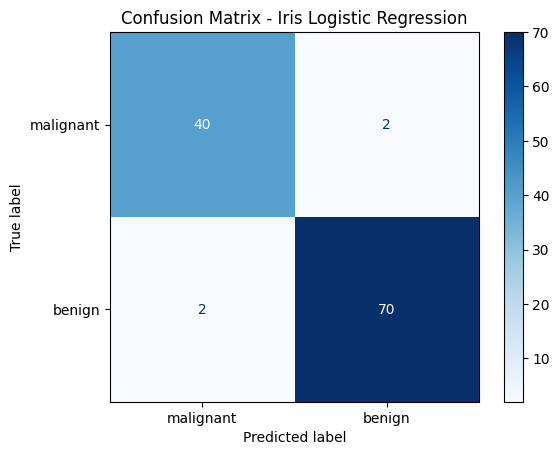

In [10]:
cm = confusion_matrix(y_test, y_pred)
print(cm)


disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=br.target_names)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix - Iris Logistic Regression")
plt.show()

In [11]:
print(classification_report(y_test, y_pred, target_names=br.target_names))

              precision    recall  f1-score   support

   malignant       0.95      0.95      0.95        42
      benign       0.97      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.96      0.96       114
weighted avg       0.96      0.96      0.96       114

